## Classification - Multiclass (attack_cat)

Workflow:
1. Load datasets and target
2. Define models via Pipeline (VarianceThreshold + SelectKBest + Classifier)
3. Run GridSearchCV to optimize Pipeline hyperparameters
4. Display collected results
5. Show confusion matrix and classification report for the best model on test set
6. Save best model

In [1]:
# 1. Load reduced datasets and target

import pandas as pd

X_train = pd.read_parquet("../data/processed/X_train.parquet")
X_test = pd.read_parquet("../data/processed/X_test.parquet")

y_train = pd.read_parquet("../data/processed/y_cat_train.parquet")['attack_cat']
y_test = pd.read_parquet("../data/processed/y_cat_test.parquet")['attack_cat']

In [2]:
# 2. Define models via Pipeline (VarianceThreshold + SelectKBest + Classifier)

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

random_state = 42

models = {
    'dt': {
        'name': 'Decision Tree',
        'estimator' : Pipeline([
            ('variance', VarianceThreshold(threshold=0)),
            ('selector', SelectKBest(score_func=f_classif)),
            ('classifier', DecisionTreeClassifier(random_state=random_state))
        ]),
        'param': [{
            'selector__k': [30, 40, 50],
            'classifier__max_depth': [5, 10, 15, 20],
            'classifier__criterion': ['entropy', 'gini'],
            'classifier__class_weight': [None, 'balanced']
        }]
    },
    'rf': {
        'name': 'Random Forest',
        'estimator': Pipeline([
            ('variance', VarianceThreshold(threshold=0)),
            ('selector', SelectKBest(score_func=f_classif)),
            ('classifier', RandomForestClassifier(random_state=random_state))
        ]),
        'param': [{
            'selector__k' : [30, 40, 50],
            'classifier__n_estimators': [20, 30, 40, 50],
            'classifier__max_depth': [5, 10, 15, None],
            'classifier__class_weight': [None, 'balanced']
        }]
    }
}

In [3]:
# 3. Run GridSearchCV to optimize Pipeline hyperparameters

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import make_scorer, precision_score, recall_score

scoring = {
    'f1_macro': 'f1_macro',
    'precision_macro' : make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro' : make_scorer(recall_score, average='macro', zero_division=0),
    'accuracy' : 'accuracy'
}

cv = StratifiedKFold(n_splits=3, random_state=random_state, shuffle=True)

clfs = {}
results = pd.DataFrame(columns=['model_lbl', 'best_params', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_macro_std'])

for model_lbl, model_info in models.items():
    print(f"Tuning {model_info['name']}...")

    clf = GridSearchCV(
        model_info['estimator'],
        model_info['param'],
        cv=cv,
        scoring=scoring,
        refit='f1_macro',
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    idx = clf.best_index_
    cv_res = clf.cv_results_
    clfs[model_lbl] = clf

    results.loc[len(results)] = [
        model_lbl,
        clf.best_params_,
        cv_res['mean_test_accuracy'][idx],
        cv_res['mean_test_precision_macro'][idx],
        cv_res['mean_test_recall_macro'][idx],
        cv_res['mean_test_f1_macro'][idx],
        cv_res['std_test_f1_macro'][idx]
    ]

print("\nDone.")

Tuning Decision Tree...
Tuning Random Forest...

Done.


In [4]:
# 4. Display the collected results

results = results.sort_values(by='f1_macro', ascending=False).reset_index(drop=True)

display(
    results.style.format(precision=3)
           .set_caption('Multiclass classification results (attack_cat)')
)

,model_lbl,best_params,accuracy,precision_macro,recall_macro,f1_macro,f1_macro_std
0,rf,"{'classifier__class_weight': 'balanced', 'classifier__max_depth': 15, 'classifier__n_estimators': 20, 'selector__k': 40}",0.778,0.542,0.626,0.552,0.012
1,dt,"{'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 15, 'selector__k': 40}",0.764,0.515,0.619,0.541,0.011


Best combination: Random Forest
Best params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 15, 'classifier__n_estimators': 20, 'selector__k': 40}

                precision    recall  f1-score   support

      Analysis       0.15      0.55      0.23       362
      Backdoor       0.18      0.36      0.24       408
           DoS       0.38      0.25      0.30      1044
      Exploits       0.87      0.76      0.81      6394
       Fuzzers       0.61      0.83      0.70      4718
       Generic       0.84      0.66      0.74       584
        Normal       0.99      0.82      0.90     16135
Reconnaissance       0.75      0.82      0.79      1962
     Shellcode       0.23      0.86      0.37       299
         Worms       0.55      0.52      0.53        46

      accuracy                           0.78     31952
     macro avg       0.56      0.64      0.56     31952
  weighted avg       0.85      0.78      0.80     31952



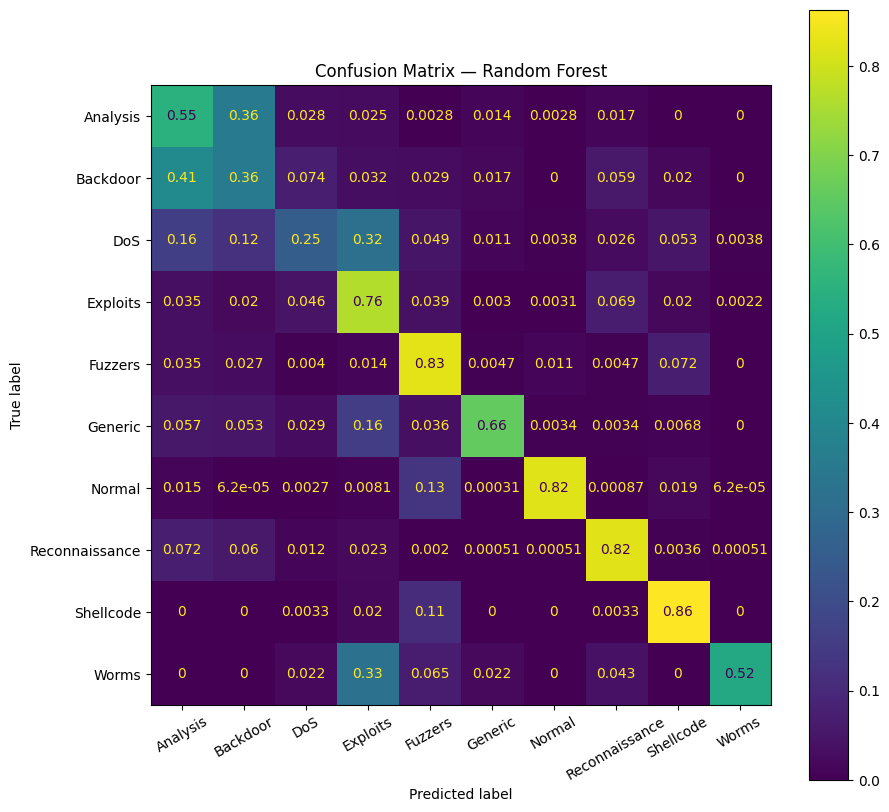

In [5]:
# 5. Show confusion matrix and classification report for the best model on test set

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

best_key = f"{results.loc[0, 'model_lbl']}"
best_label = models[best_key]['name']
best_clf = clfs[best_key]

y_pred_best = best_clf.predict(X_test)

print(f"Best combination: {best_label}")
print(f"Best params: {results.loc[0, 'best_params']}")
print()
print(classification_report(y_test, y_pred_best, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    normalize='true',
    ax=ax,
    xticks_rotation=30)
disp.ax_.set_title(f"Confusion Matrix — {best_label}")
plt.show()

In [6]:
# 6. Save best model

import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_clf, "../models/best_model_mlt.pkl")
print("Best binary model saved to ../models/best_model_mlt.pkl")

Best binary model saved to ../models/best_model_mlt.pkl
